In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [11]:
# Phonon calculations indicate that only the buckled B substitution lattices are stable
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [39]:
wbandsup22bc = np.loadtxt("$bn22bc_dir/Wannier/EsUp.txt");
wbandsdn22bc = np.loadtxt("$bn22bc_dir/Wannier/EsDn.txt");
EsDn22bc, DOSDn22bc = np.loadtxt("$bn22bc_dir/Wannier/DosDn.txt");
EsUp22bc, DOSUp22bc = np.loadtxt("$bn22bc_dir/Wannier/DosUp.txt");

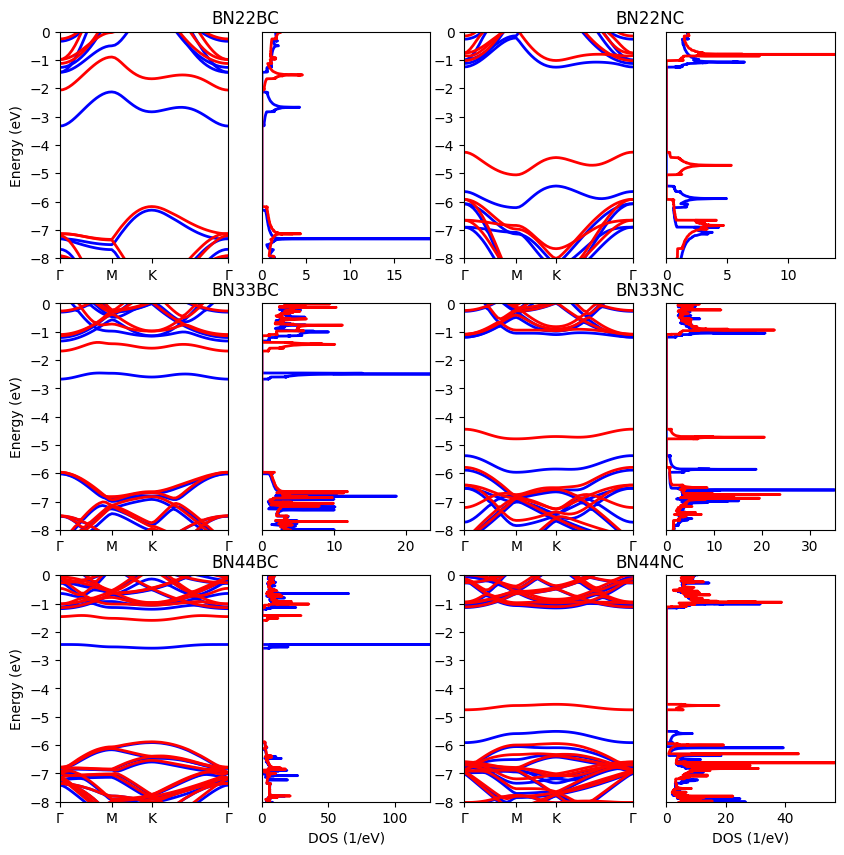

In [38]:
figure(figsize=(10, 10))

bands_overlayed_dos(bn22bc_dir*"/DOS/BN22BC.dosUp", bn22bc_dir*"/DOS/BN22BC.dosDn", bn22bc_dir*"/BN22BC.bands.eigenvals"
, energy_range = (-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 1], dos_subplot=[3, 4, 2], dos_yticks=false)
xlabel("")
title("BN22BC", y=1, x = -0.1)

bands_overlayed_dos(bn33bc_dir*"/DOS/BN33BC.dosUp", bn33bc_dir*"/DOS/BN33BC.dosDn", bn33bc_dir*"/BN33BC.bands.eigenvals"
, energy_range=(-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 5], dos_subplot=[3, 4, 6], dos_yticks=false)
xlabel("")
title("BN33BC", y=1, x = -0.1)

bands_overlayed_dos(bn44bc_dir*"/DOS/BN44BC.dosUp", bn44bc_dir*"/DOS/BN44BC.dosDn", bn44bc_dir*"/BN44BC.bands.eigenvals"
, energy_range=(-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 9], dos_subplot=[3, 4, 10], dos_yticks=false)
title("BN44BC", y=1, x = -0.1)


bands_overlayed_dos(bn22nc_dir*"/DOS/BN22NC.dosUp", bn22nc_dir*"/DOS/BN22NC.dosDn", bn22nc_dir*"/BN22NC.bands.eigenvals"
, energy_range = (-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 3], dos_subplot=[3, 4, 4], dos_yticks=false)
xlabel("")
title("BN22NC", y=1, x = -0.1)


bands_overlayed_dos(bn33nc_dir*"/DOS/BN33NC.dosUp", bn33nc_dir*"/DOS/BN33NC.dosDn", bn33nc_dir*"/BN33NC.bands.eigenvals"
, energy_range = (-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 7], dos_subplot=[3, 4, 8], dos_yticks=false)
xlabel("")
title("BN33NC", y=1, x = -0.1)


bands_overlayed_dos(bn44nc_dir*"/DOS/BN44NC.dosUp", bn44nc_dir*"/DOS/BN44NC.dosDn", bn44nc_dir*"/BN44NC.bands.eigenvals"
, energy_range = (-8, 0), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 4, 11], dos_subplot=[3, 4, 12], dos_yticks=false)
#savefig("BNxxNC-Bands.pdf")
title("BN44NC", y=1, x = -0.1)

subplot(3, 4, 11)
ylabel("")
subplot(3, 4, 7)
ylabel("")
subplot(3, 4, 3)
ylabel("")
#savefig("AllBands.pdf")
#savefig("BNxxBC-Bands.svg")
#savefig("BNxxBC-Bands.pdf")

In [10]:
Energies22=zeros(100)
Magnetizations22=zeros(100)
for i in 1:100
    Magnetizations22[i] = get_mag("$bn22bc_dir/magnetization/BN22BC-$i.out")
    Energies22[i] = list_energy("$bn22bc_dir/magnetization/BN22BC-$i.out")
end

In [11]:
Energies33=zeros(100)
Magnetizations33=zeros(100)
for i in 1:100
    #println(i)
    try
    Magnetizations33[i] = get_mag("$bn33bc_dir/magnetization/BN33BC-$i.out")
    Energies33[i] = list_energy("$bn33bc_dir/magnetization/BN33BC-$i.out")
    catch
    end
end

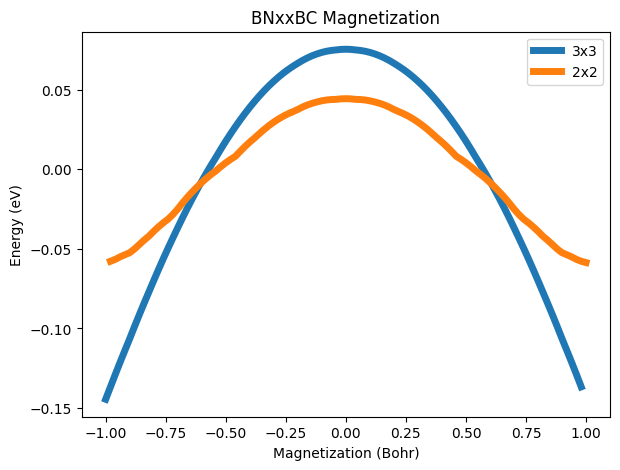

PyObject Text(0.5, 24.0, 'Magnetization (Bohr)')

In [17]:
figure(figsize=(15, 5))
subplot(1, 2, 1)
plot(Magnetizations33, Energies33 .-  mean(Energies33), linewidth=5, label="3x3")
title("BN33BC Magnetization")
ylabel("Energy (eV)")
title("BN33BC Magnetization")
xlabel("Magnetization (Bohr)")
#subplot(1, 2, 2)
plot(Magnetizations22, Energies22 .- mean(Energies22), linewidth=5, label="2x2")
ylabel("Energy (eV)")
title("BNxxBC Magnetization")
legend()
xlabel("Magnetization (Bohr)")